In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

train_df = pd.read_csv('/content/train (1).csv')
test_df = pd.read_csv('/content/test_features (1).csv')

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df.head())

Train shape: (800, 19)
Test shape: (200, 18)
   patient_id  Возраст  Пол_мужской    ИМТ  Окружность_талии_см  САД_мм_рт_ст  \
0           1       41            1  24.24                81.04        113.19   
1           4       53            0  19.84                73.44        119.75   
2           5       53            1  24.28                82.06        127.07   
3           6       60            1  25.19                91.89        116.98   
4           7       59            1  24.45                84.07        129.12   

   ДАД_мм_рт_ст  Пульсовое_давление  Глюкоза_натощак_ммоль_л  HbA1c_%  \
0         62.54               50.65                    4.595     4.65   
1         71.59               48.15                    4.431     5.08   
2         70.34               56.73                    4.997     5.04   
3         82.00               34.98                    5.491     5.00   
4         82.70               46.42                    6.456     4.80   

   ЛПНП_ммоль_л  ЛПВП_ммоль_л

In [4]:

X = train_df.drop(columns=['patient_id', 'prediction', 'Статус_глюкозы', 'Доклинический_риск'], errors='ignore')
y = train_df['prediction']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)

X_train_t = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_val_t = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_t = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)

batch_size = 64
train_dataset = TensorDataset(X_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [5]:
class RiskFFN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = RiskFFN(X_train_t.shape[1]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [6]:
epochs = 100
train_losses, val_losses = [], []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

    epoch_train_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    epoch_val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {epoch_train_loss:.4f}, Val Loss: {epoch_val_loss:.4f}")

Epoch 20/100 - Train Loss: 0.1623, Val Loss: 0.1779
Epoch 40/100 - Train Loss: 0.0874, Val Loss: 0.1578
Epoch 60/100 - Train Loss: 0.0690, Val Loss: 0.1491
Epoch 80/100 - Train Loss: 0.0476, Val Loss: 0.1683
Epoch 100/100 - Train Loss: 0.0285, Val Loss: 0.1769


Оценка на валидационной выборке:
Accuracy:  0.9563
Precision: 0.9231
Recall:    0.8276
F1-score:  0.8727
ROC-AUC:   0.9755

Confusion Matrix:
[[129   2]
 [  5  24]]


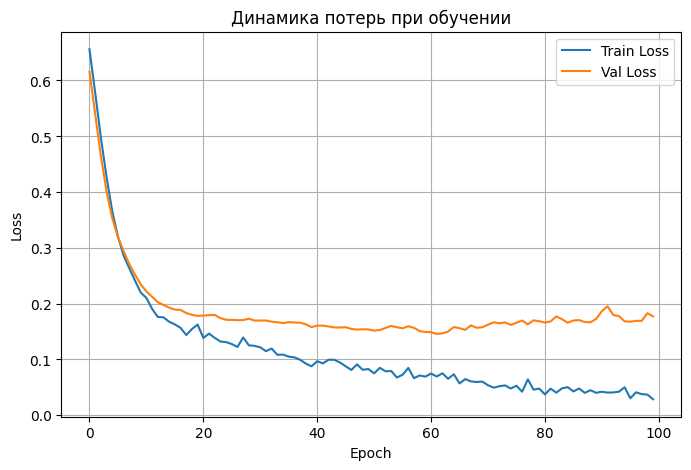

In [7]:
model.eval()
y_pred_probs = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        probs = torch.sigmoid(outputs).cpu().numpy()
        y_pred_probs.extend(probs.flatten())
        y_true.extend(y_batch.numpy().flatten())

y_pred_probs = np.array(y_pred_probs)
y_true = np.array(y_true)

y_pred_class = (y_pred_probs >= 0.5).astype(int)

print("Оценка на валидационной выборке:")
print(f"Accuracy:  {accuracy_score(y_true, y_pred_class):.4f}")
print(f"Precision: {precision_score(y_true, y_pred_class):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred_class):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred_class):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_true, y_pred_probs):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_class))

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Динамика потерь при обучении')
plt.legend()
plt.grid(True)
plt.show()